# Image Basics & OpenCV

## What is an Image?
A digital image is a 2D (or 3D) array of pixel values. Grayscale images have shape `(H, W)`, color images have shape `(H, W, C)` where C=3 for RGB/BGR.

- **Pixel value range**: 0-255 for uint8, 0.0-1.0 for float32
- **OpenCV loads images in BGR** (not RGB) a common gotcha

---

## Color Spaces

| Space | Channels | Use Case |
|-------|----------|----------|
| RGB | Red, Green, Blue | Display, deep learning |
| BGR | Blue, Green, Red | OpenCV default |
| HSV | Hue, Saturation, Value | Color filtering |
| LAB | Lightness, A, B | Perceptual uniformity |
| Grayscale | Intensity | Edge detection, thresholding |

**RGB → Grayscale** (luminosity method):
$$Y = 0.299 R + 0.587 G + 0.114 B$$

**RGB → HSV**:
$$V = \max(R,G,B), \quad S = \frac{V - \min(R,G,B)}{V}, \quad H = \text{(angle based on dominant channel)}$$

---

## Geometric Transformations

**Affine transformation** (rotation, translation, scale):
$$\begin{bmatrix} x' \\ y' \end{bmatrix} = M \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}, \quad M = \begin{bmatrix} a & b & t_x \\ c & d & t_y \end{bmatrix}$$

**Rotation matrix** by angle $\theta$:
$$M_r = \begin{bmatrix} \cos\theta & -\sin\theta & t_x \\ \sin\theta & \cos\theta & t_y \end{bmatrix}$$

---

## Image Filtering

**2D Convolution / Correlation**:
$$G[i,j] = \sum_m \sum_n I[i+m, j+n] \cdot K[m,n]$$

**Gaussian Blur** smooths noise, uses Gaussian kernel:
$$G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}$$

**Bilateral Filter** edge-preserving smoothing:
$$BF[I]_p = \frac{1}{W_p} \sum_{q \in S} G_\sigma(||p-q||) \cdot G_r(|I_p - I_q|) \cdot I_q$$

---

## Edge Detection

**Sobel operator** (x and y gradients):
$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

**Gradient magnitude**: $G = \sqrt{G_x^2 + G_y^2}$

**Canny edge detector** steps:
1. Gaussian smoothing
2. Gradient computation (Sobel)
3. Non-maximum suppression
4. Double thresholding (low, high)
5. Hysteresis edge tracking

---

## Harris Corner Detector

Structure tensor $M$:
$$M = \sum_{(x,y) \in W} \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$$

Corner response:
$$R = \det(M) - k(\text{trace}(M))^2 = \lambda_1\lambda_2 - k(\lambda_1+\lambda_2)^2$$

- $R > 0$: corner
- $R < 0$: edge
- $|R| \approx 0$: flat region

---

## HOG Features (Histogram of Oriented Gradients)

1. Compute gradient magnitudes and orientations
2. Divide image into cells (e.g., 8×8)
3. Build histogram of gradient orientations per cell (9 bins)
4. Normalize over blocks (2×2 cells)
5. Concatenate to form feature vector

Normalization: $$v_{normalized} = \frac{v}{\sqrt{||v||^2_2 + \epsilon^2}}$$

---

## Morphological Operations

**Erosion**: $A \ominus B = \{z | B_z \subseteq A\}$ shrinks bright regions  
**Dilation**: $A \oplus B = \{z | \hat{B}_z \cap A \neq \emptyset\}$ expands bright regions  
**Opening** = Erosion then Dilation (removes noise)  
**Closing** = Dilation then Erosion (fills holes)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a sample image for demonstration
img_bgr = np.zeros((300, 300, 3), dtype=np.uint8)
cv2.rectangle(img_bgr, (50, 50), (150, 150), (0, 255, 0), -1)
cv2.circle(img_bgr, (200, 200), 60, (0, 0, 255), -1)
cv2.putText(img_bgr, 'CV', (100, 270), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

print('Image shape (H, W, C):', img_bgr.shape)
print('Dtype:', img_bgr.dtype)
print('Min/Max:', img_bgr.min(), img_bgr.max())

Image shape (H, W, C): (300, 300, 3)
Dtype: uint8
Min/Max: 0 255


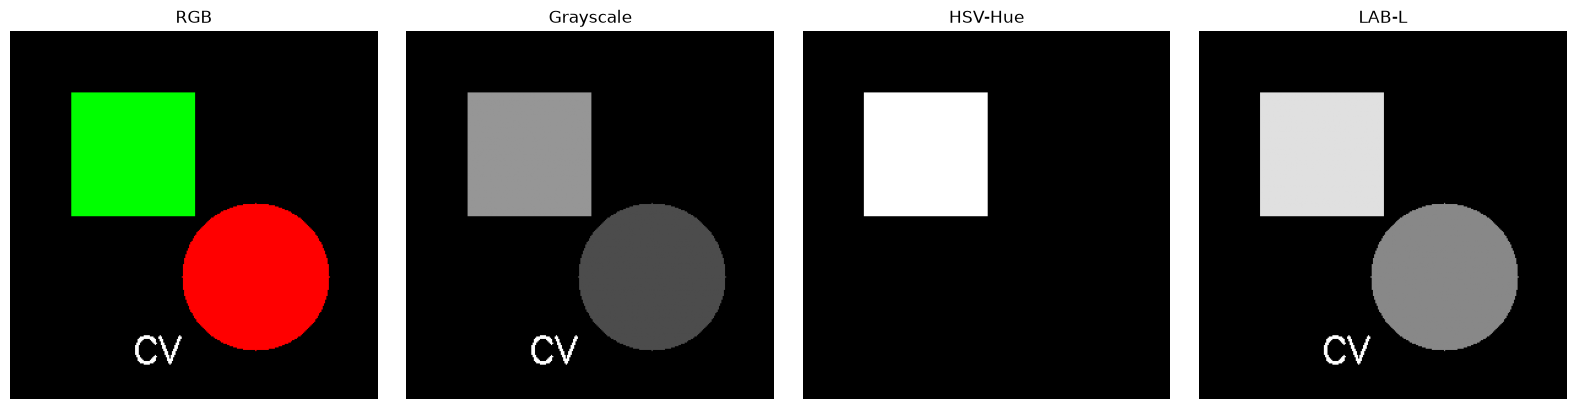

In [2]:
# Color space conversions
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, title in zip(axes,
                          [img_rgb, img_gray, img_hsv[:,:,0], img_lab[:,:,0]],
                          ['RGB', 'Grayscale', 'HSV-Hue', 'LAB-L']):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

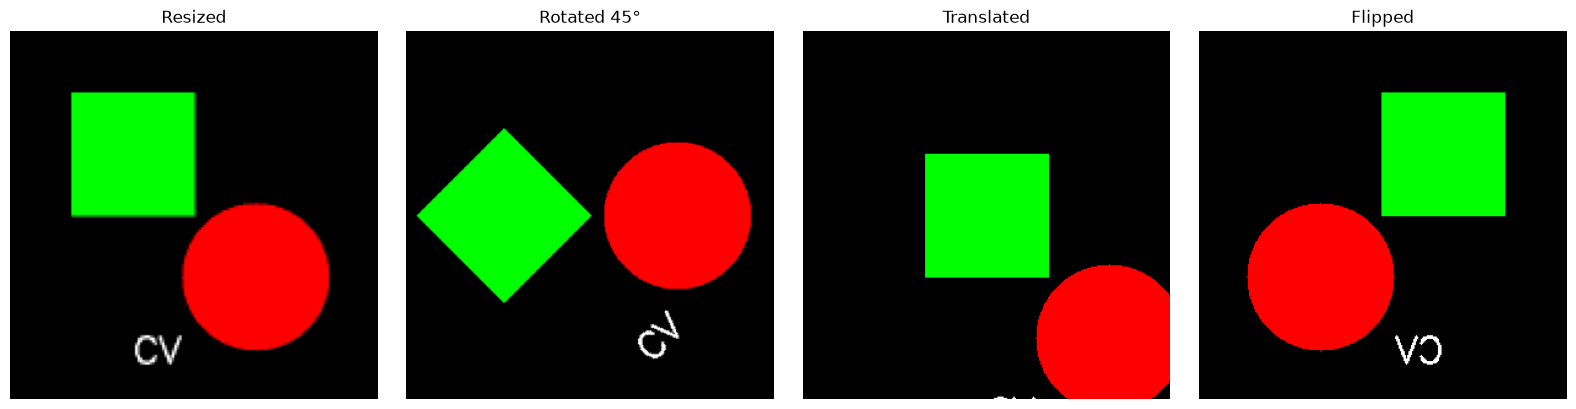

In [3]:
# Geometric transformations
h, w = img_rgb.shape[:2]

# Resize
resized = cv2.resize(img_rgb, (150, 150))

# Rotation around center
M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle=45, scale=1.0)
rotated = cv2.warpAffine(img_rgb, M_rot, (w, h))

# Translation
M_trans = np.float32([[1, 0, 50], [0, 1, 50]])
translated = cv2.warpAffine(img_rgb, M_trans, (w, h))

# Flip: 0=vertical, 1=horizontal, -1=both
flipped = cv2.flip(img_rgb, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, title in zip(axes, [resized, rotated, translated, flipped],
                          ['Resized', 'Rotated 45°', 'Translated', 'Flipped']):
    ax.imshow(im); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

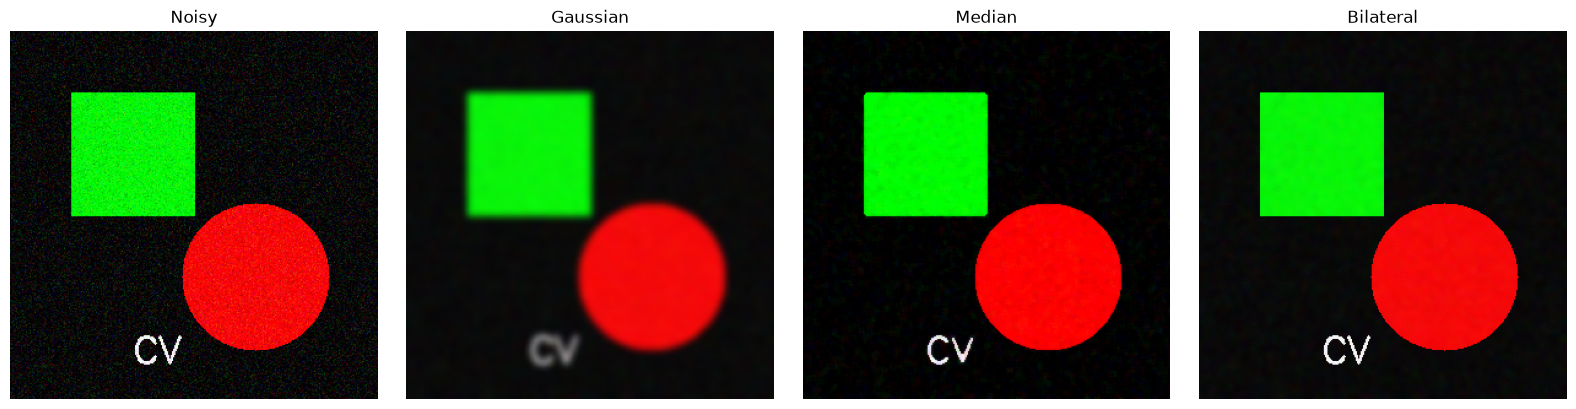

In [4]:
# Image filtering
noisy = img_rgb.copy().astype(np.float32)
noisy += np.random.normal(0, 25, noisy.shape)
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

gaussian = cv2.GaussianBlur(noisy, (15, 15), sigmaX=3)
median   = cv2.medianBlur(noisy, 5)
bilateral = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, t in zip(axes, [noisy, gaussian, median, bilateral],
                      ['Noisy', 'Gaussian', 'Median', 'Bilateral']):
    ax.imshow(im); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

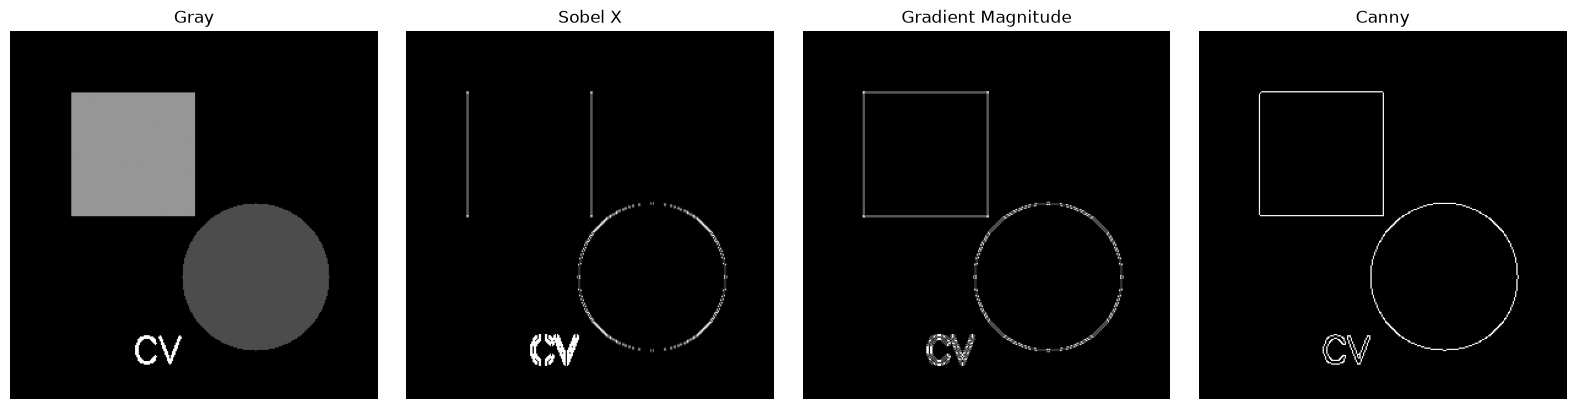

In [5]:
# Edge detection
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

sobel_x  = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y  = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
gradient = np.sqrt(sobel_x**2 + sobel_y**2).astype(np.uint8)
canny    = cv2.Canny(gray, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, t in zip(axes, [gray, np.abs(sobel_x).astype(np.uint8), gradient, canny],
                      ['Gray', 'Sobel X', 'Gradient Magnitude', 'Canny']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

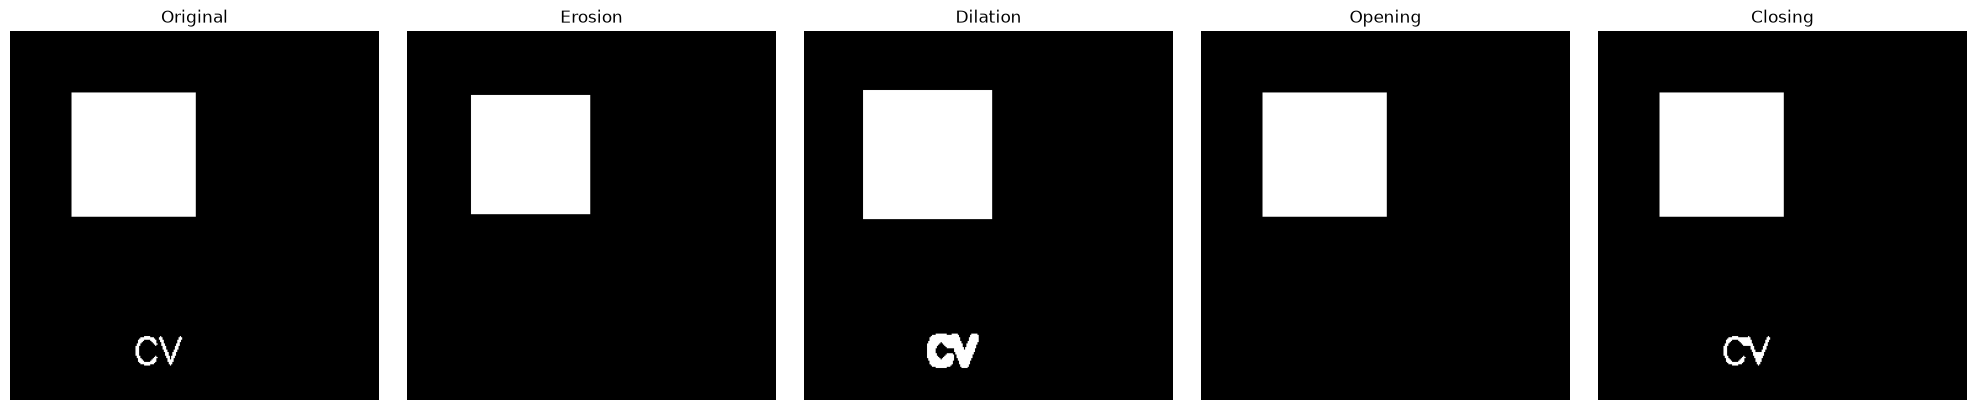

In [6]:
# Morphological operations
kernel = np.ones((5, 5), np.uint8)
binary = (gray > 100).astype(np.uint8) * 255

eroded   = cv2.erode(binary, kernel, iterations=1)
dilated  = cv2.dilate(binary, kernel, iterations=1)
opened   = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed   = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, im, t in zip(axes, [binary, eroded, dilated, opened, closed],
                      ['Original', 'Erosion', 'Dilation', 'Opening', 'Closing']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

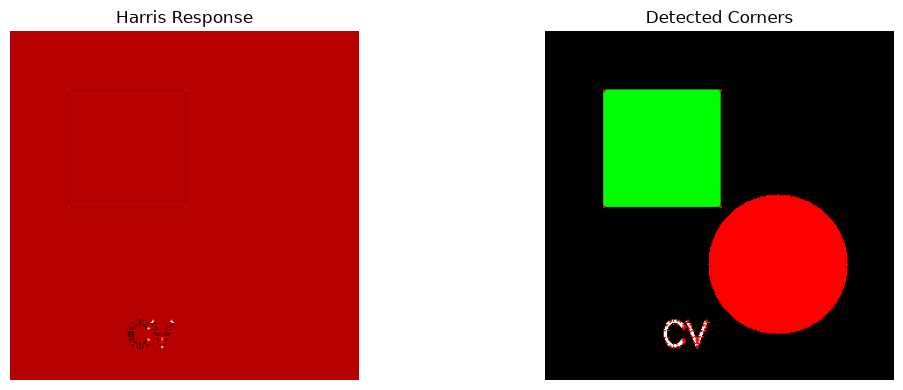

In [7]:
# Harris Corner Detection
gray_f = np.float32(gray)
harris = cv2.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04)
harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# Mark corners on image
img_corners = img_rgb.copy()
img_corners[harris > 0.01 * harris.max()] = [255, 0, 0]  # red dots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(harris_norm, cmap='hot'); ax1.set_title('Harris Response'); ax1.axis('off')
ax2.imshow(img_corners); ax2.set_title('Detected Corners'); ax2.axis('off')
plt.tight_layout(); plt.show()

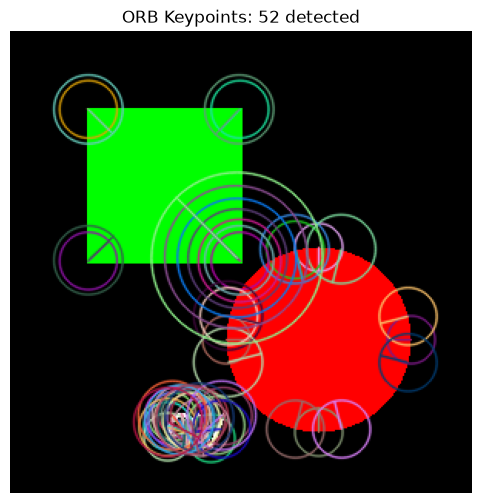

Descriptor shape: (52, 32)


In [8]:
# ORB Feature Detection (SIFT/SURF patent-free alternative)
orb = cv2.ORB_create(nfeatures=500)
keypoints, descriptors = orb.detectAndCompute(gray, None)

img_kp = cv2.drawKeypoints(img_rgb, keypoints, None,
                            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(8, 6))
plt.imshow(img_kp)
plt.title(f'ORB Keypoints: {len(keypoints)} detected')
plt.axis('off'); plt.show()
print('Descriptor shape:', descriptors.shape if descriptors is not None else 'None')

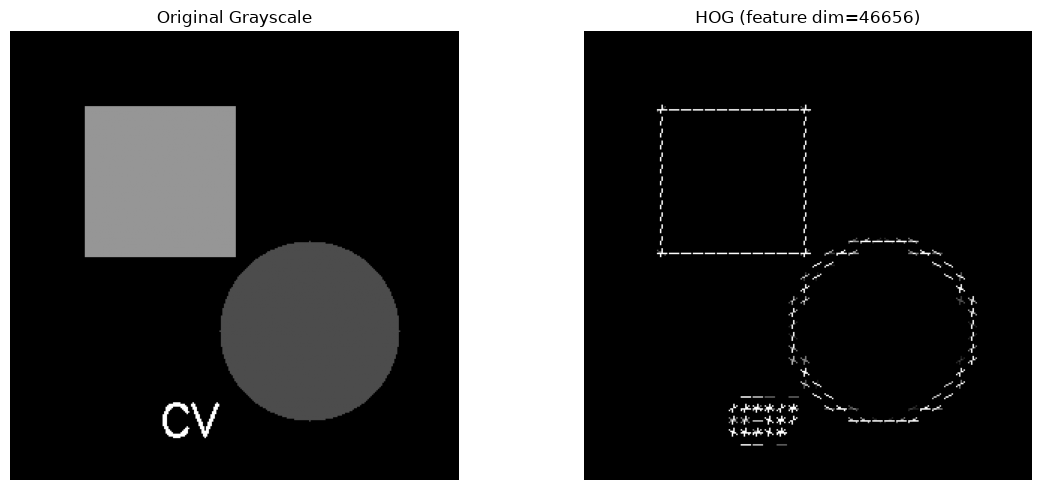

In [9]:
# HOG Features
from skimage.feature import hog
from skimage import exposure

hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    channel_axis=None
)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(gray, cmap='gray'); ax1.set_title('Original Grayscale'); ax1.axis('off')
ax2.imshow(hog_image_rescaled, cmap='gray'); ax2.set_title(f'HOG (feature dim={len(hog_features)})'); ax2.axis('off')
plt.tight_layout(); plt.show()

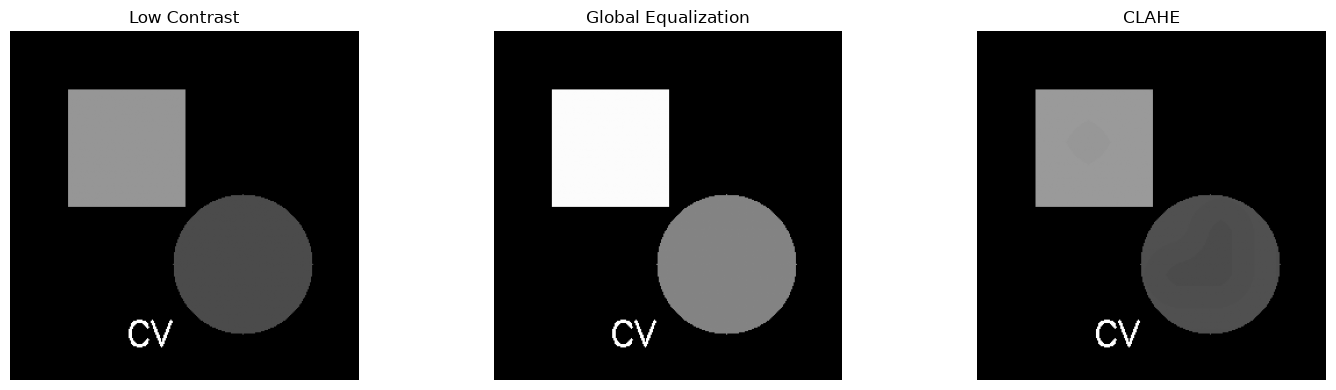

In [10]:
# Histogram Equalization & CLAHE
# Create a low-contrast image
low_contrast = (gray * 0.4 + 50).astype(np.uint8)

eq_global = cv2.equalizeHist(low_contrast)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
eq_clahe = clahe.apply(low_contrast)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, im, t in zip(axes, [low_contrast, eq_global, eq_clahe],
                      ['Low Contrast', 'Global Equalization', 'CLAHE']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

Found 3 contours
  Contour 0: area=80.0, perimeter=98.9
  Contour 1: area=104.0, perimeter=106.6
  Contour 2: area=10000.0, perimeter=400.0


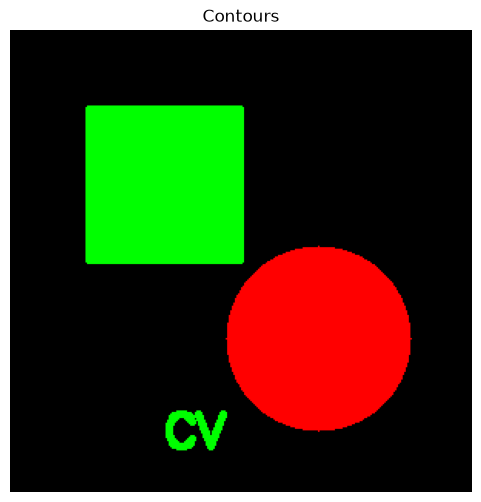

In [11]:
# Contour Detection
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

print(f'Found {len(contours)} contours')
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    print(f'  Contour {i}: area={area:.1f}, perimeter={perimeter:.1f}')

plt.figure(figsize=(6, 6))
plt.imshow(img_contours); plt.title('Contours'); plt.axis('off'); plt.show()

## Additional Learning Resources

### Official Documentation
- [OpenCV Documentation](https://docs.opencv.org/4.x/) Complete OpenCV reference
- [OpenCV Python Tutorials](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html) Official Python tutorials
- [scikit-image Docs](https://scikit-image.org/docs/stable/) Scientific image processing

### Books
- [Learning OpenCV 4 (O'Reilly)](https://www.oreilly.com/library/view/learning-opencv-4/9781491937945/) Gary Bradski & Adrian Kaehler
- [Computer Vision: Algorithms and Applications](https://szeliski.org/Book/) Richard Szeliski (free PDF)
- [Programming Computer Vision with Python](http://programmingcomputervision.com/) Jan Erik Solem (free)

### Courses
- [CS231n: CNNs for Visual Recognition](http://cs231n.stanford.edu/) Stanford
- [First Principles of Computer Vision (Columbia)](https://www.youtube.com/channel/UCf0WB91t8Ky6AuYcQV0CcLw) YouTube series
- [OpenCV Bootcamp](https://opencv.org/university/free-opencv-course/) Free official course

### Papers
- [SIFT: Distinctive Image Features from Scale-Invariant Keypoints](https://link.springer.com/article/10.1023/B:VISI.0000029664.99615.94) Lowe 2004
- [HOG for Human Detection](https://inria.hal.science/inria-00548512/document) Dalal & Triggs 2005
- [Harris & Stephens Corner Detector](https://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.434.4937&rep=rep1&type=pdf) 1988
- [Canny Edge Detection](https://ieeexplore.ieee.org/document/4767851) Canny 1986

### Blogs & Tutorials
- [PyImageSearch](https://pyimagesearch.com/) Adrian Rosebrock's practical CV tutorials
- [LearnOpenCV](https://learnopencv.com/) Satya Mallick's OpenCV blog
- [Towards Data Science CV posts](https://towardsdatascience.com/tagged/computer-vision)
